# Compare Edge Flipability Across Score Tiers

For an edge inside one $K_5$, let $k$ be the number of edges in that $K_5$ having the edge's current color. Its discrete local flipability is $k-1$. The global flipability of an edge is the sum over every $K_5$ containing it.

The exact role profile $(N_1,\ldots,N_{10})$ is retained as well. $N_k$ counts incident $K_5$s in which exactly $k$ edges have the edge's current color.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramsey import (
    RGraph,
    RProblem,
    RRandomConstruction,
    RSQLiteArchive,
    RSearchState,
)
from ramsey.REdgeFlipability import calculate_edge_flipability

N_VERTICES = 43
RANDOM_SEED = 202_608_071
SAMPLES_PER_TIER = 20
RANDOM_SAMPLES = 20

SCORE_TIERS = (
    (0, 149),
    (150, 199),
    (200, 249),
    (250, 299),
    (300, 399),
    (400, 599),
)

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

DATABASE_PATH = project_root / 'data' / 'ramsey_colorings.sqlite3'
rng = np.random.default_rng(RANDOM_SEED)


In [2]:
graph_start = perf_counter()
graph = RGraph(RProblem.r55(n_vertices=N_VERTICES))
graph_elapsed = perf_counter() - graph_start

archive = RSQLiteArchive(DATABASE_PATH)
random_construction = RRandomConstruction(rng)

print('Database:', DATABASE_PATH.resolve())
print('Archive colorings:', archive.coloring_count(graph))
print('Archive best:', archive.best_score(graph))
print('Graph setup:', f'{graph_elapsed:.3f}s')


Database: C:\code\RamseyNumber\data\ramsey_colorings.sqlite3
Archive colorings: 3261
Archive best: 129
Graph setup: 1.417s


In [3]:
selected = []

for minimum_score, maximum_score in SCORE_TIERS:
    records = archive.colorings_in_score_range(
        minimum_score=minimum_score,
        maximum_score=maximum_score,
        graph=graph,
    )

    if len(records) > SAMPLES_PER_TIER:
        indexes = rng.choice(
            len(records),
            size=SAMPLES_PER_TIER,
            replace=False,
        )
        records = [records[int(index)] for index in indexes]

    tier = f'{minimum_score}-{maximum_score}'
    selected.extend((tier, record) for record in records)
    print(tier, 'selected:', len(records))

print('Archived states selected:', len(selected))
print('Random controls:', RANDOM_SAMPLES)


0-149 selected: 20
150-199 selected: 20
200-249 selected: 0
250-299 selected: 20
300-399 selected: 20
400-599 selected: 20
Archived states selected: 100
Random controls: 20


In [4]:
analyses = {}
rows = []
analysis_start = perf_counter()

def record_state(state, *, tier, state_id):
    analysis = calculate_edge_flipability(state)
    analyses[state_id] = analysis

    for edge, flipability in enumerate(analysis.flipabilities):
        rows.append({
            'state_id': state_id,
            'tier': tier,
            'score': state.score,
            'edge': edge,
            'flipability': int(flipability),
        })

for index, (tier, record) in enumerate(selected, start=1):
    archived = archive.load_coloring(record.coloring_id, graph)
    state = RSearchState(archived.coloring)
    record_state(
        state,
        tier=tier,
        state_id=record.coloring_id,
    )
    print(
        f'{index:3d}/{len(selected):3d} | '
        f'id={record.coloring_id:5d} | '
        f'score={state.score:4d} | {tier}'
    )

for random_index in range(RANDOM_SAMPLES):
    state = RSearchState(random_construction.construct(graph))
    record_state(
        state,
        tier='random',
        state_id=f'random-{random_index:03d}',
    )

analysis_elapsed = perf_counter() - analysis_start
edge_frame = pd.DataFrame(rows)

print()
print('States analyzed:', len(analyses))
print('Edge observations:', f'{len(edge_frame):,}')
print('Elapsed:', f'{analysis_elapsed:.3f}s')


  1/100 | id= 2652 | score= 146 | 0-149
  2/100 | id= 2837 | score= 147 | 0-149
  3/100 | id= 2796 | score= 149 | 0-149
  4/100 | id= 2946 | score= 146 | 0-149
  5/100 | id= 2893 | score= 146 | 0-149
  6/100 | id= 3063 | score= 138 | 0-149
  7/100 | id= 3189 | score= 140 | 0-149
  8/100 | id= 3100 | score= 138 | 0-149
  9/100 | id= 3198 | score= 145 | 0-149
 10/100 | id= 3035 | score= 148 | 0-149
 11/100 | id= 3048 | score= 144 | 0-149
 12/100 | id= 2961 | score= 146 | 0-149
 13/100 | id= 3004 | score= 143 | 0-149
 14/100 | id= 3122 | score= 148 | 0-149
 15/100 | id= 3088 | score= 147 | 0-149
 16/100 | id= 3027 | score= 149 | 0-149
 17/100 | id= 3234 | score= 143 | 0-149
 18/100 | id= 3196 | score= 137 | 0-149
 19/100 | id= 2985 | score= 147 | 0-149
 20/100 | id= 2870 | score= 146 | 0-149
 21/100 | id= 2346 | score= 168 | 150-199
 22/100 | id= 2842 | score= 151 | 150-199
 23/100 | id= 2282 | score= 164 | 150-199
 24/100 | id= 2147 | score= 169 | 150-199
 25/100 | id= 2205 | score= 174 

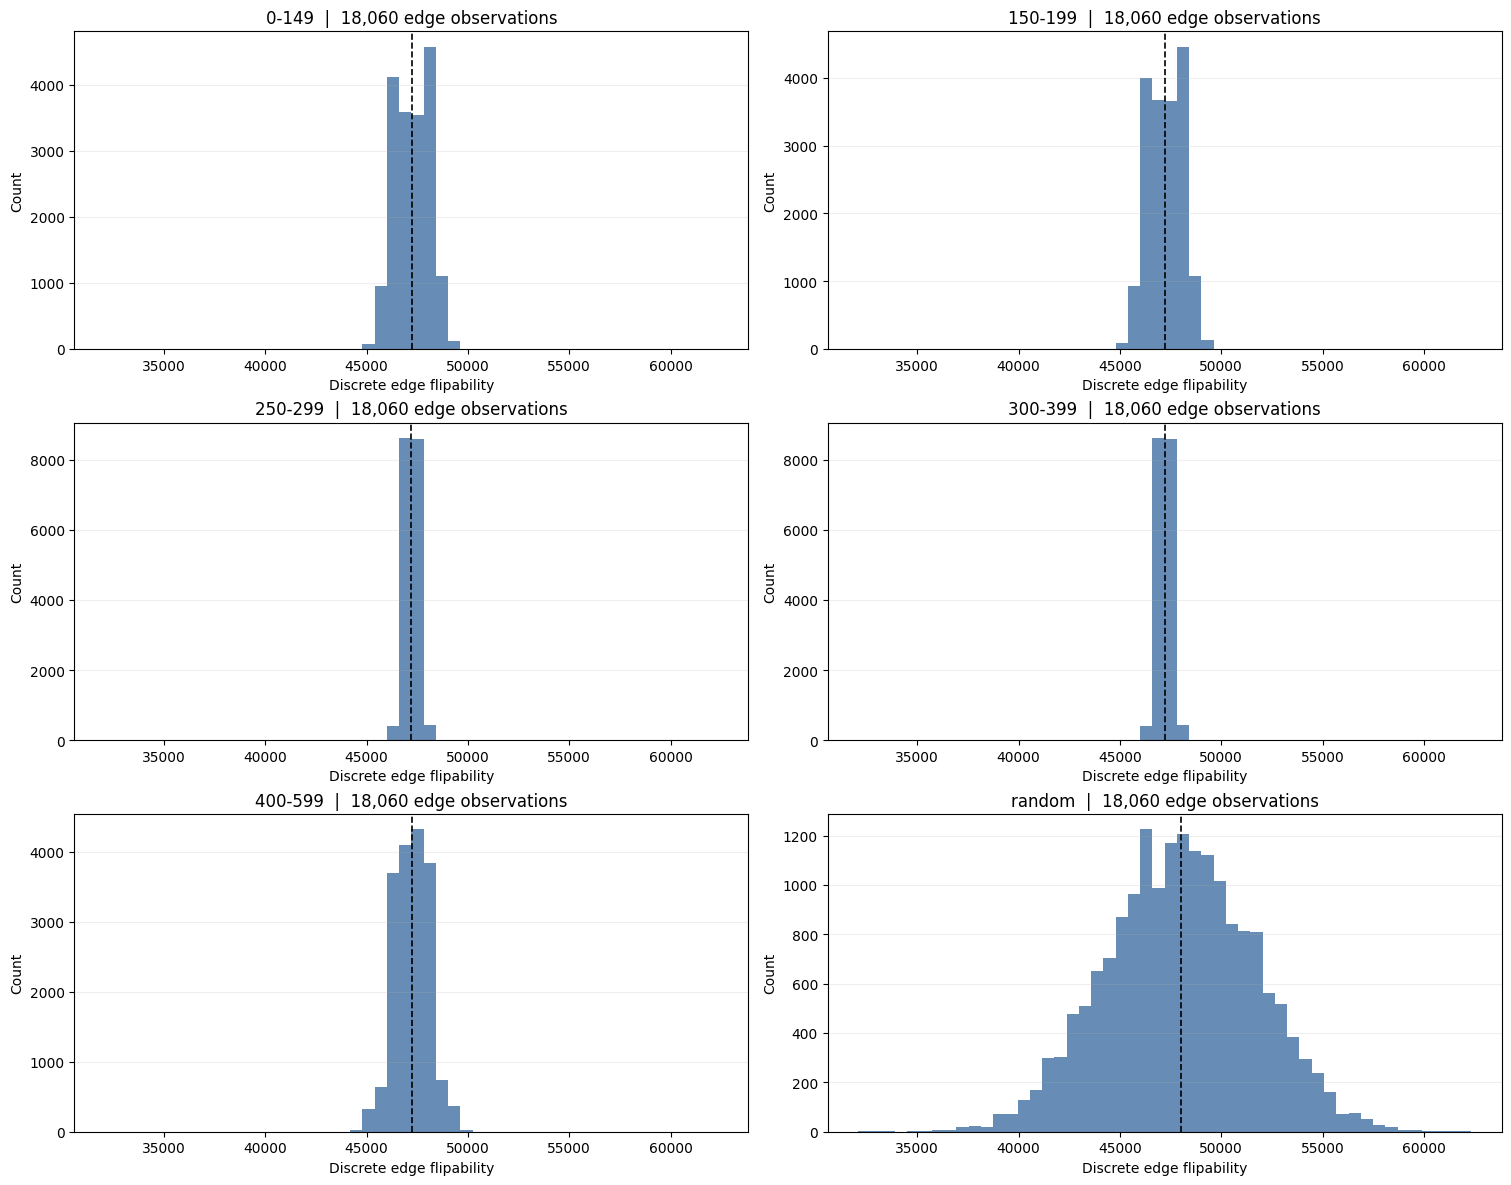

In [5]:
tier_order = [
    f'{minimum}-{maximum}'
    for minimum, maximum in SCORE_TIERS
] + ['random']

available_tiers = [
    tier for tier in tier_order
    if not edge_frame[edge_frame['tier'] == tier].empty
]

all_values = edge_frame['flipability'].to_numpy()
bin_count = 50
bin_edges = np.linspace(
    int(all_values.min()),
    int(all_values.max()) + 1,
    bin_count + 1,
)

fig, axes = plt.subplots(
    4,
    2,
    figsize=(15, 15),
    constrained_layout=True,
)
axes = list(axes.flat)

for ax, tier in zip(axes, available_tiers):
    values = edge_frame.loc[
        edge_frame['tier'] == tier,
        'flipability',
    ].to_numpy()
    ax.hist(values, bins=bin_edges, color='#4c78a8', alpha=0.85)
    ax.axvline(values.mean(), color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f'{tier}  |  {len(values):,} edge observations')
    ax.set_xlabel('Discrete edge flipability')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.2)

for ax in axes[len(available_tiers):]:
    ax.set_visible(False)

plt.show()


In [6]:
# Exact N1..N10 role-profile means by tier.
role_rows = []

for tier in available_tiers:
    state_ids = edge_frame.loc[
        edge_frame['tier'] == tier,
        'state_id',
    ].drop_duplicates()
    profiles = np.concatenate([
        analyses[state_id].role_profiles
        for state_id in state_ids
    ], axis=0)
    row = {'tier': tier}
    for k, mean_count in enumerate(profiles.mean(axis=0), start=1):
        row[f'N{k}'] = mean_count
    role_rows.append(row)

role_frame = pd.DataFrame(role_rows).set_index('tier')
display(role_frame.round(2))


,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10
tier,,,,,,,,,,
0-149,13.13,150.59,718.06,1817.26,2837.51,2725.89,1675.48,602.35,118.13,1.60
150-199,13.05,150.70,718.40,1816.82,2837.51,2725.23,1676.26,602.80,117.43,1.82
250-299,11.81,150.51,715.93,1826.07,2834.42,2739.10,1670.51,602.05,106.32,3.26
300-399,11.75,150.44,715.99,1826.73,2833.15,2740.09,1670.64,601.76,105.74,3.71
400-599,11.85,150.45,721.49,1828.62,2806.69,2742.93,1683.47,601.79,106.66,6.05
random,21.04,188.77,750.05,1747.15,2617.01,2620.72,1750.11,755.07,189.36,20.74


In [7]:
# Plain-text final report for copying back into ChatGPT.
print('EDGE FLIPABILITY TIER REPORT')
print('=' * 80)

for tier in available_tiers:
    tier_frame = edge_frame[edge_frame['tier'] == tier]
    values = tier_frame['flipability'].to_numpy()
    state_count = tier_frame['state_id'].nunique()
    q = np.quantile(
        values,
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99],
    )

    print()
    print(f'Tier: {tier}')
    print(f'  States: {state_count}')
    print(f'  Edge observations: {len(values):,}')
    print(f'  Mean: {values.mean():.2f}')
    print(f'  Std: {values.std():.2f}')
    print(f'  Min: {int(values.min())}')
    print(
        '  Quantiles: '
        f'p01={q[0]:.1f}, p05={q[1]:.1f}, p25={q[2]:.1f}, '
        f'p50={q[3]:.1f}, p75={q[4]:.1f}, p95={q[5]:.1f}, p99={q[6]:.1f}'
    )
    print(f'  Max: {int(values.max())}')

    role = role_frame.loc[tier]
    print('  Mean role profile per edge:')
    print(
        '   ' + ', '.join(
            f'N{k}={role[f"N{k}"]:.2f}'
            for k in range(1, 11)
        )
    )

print()
print('Identity check: greedy single-flip reward = N10 - N1.')


EDGE FLIPABILITY TIER REPORT

Tier: 0-149
  States: 20
  Edge observations: 18,060
  Mean: 47246.77
  Std: 762.34
  Min: 44226
  Quantiles: p01=45630.0, p05=45786.0, p25=46527.0, p50=47229.0, p75=47931.0, p95=48672.0, p99=48789.0
  Max: 50232
  Mean role profile per edge:
   N1=13.13, N2=150.59, N3=718.06, N4=1817.26, N5=2837.51, N6=2725.89, N7=1675.48, N8=602.35, N9=118.13, N10=1.60

Tier: 150-199
  States: 20
  Edge observations: 18,060
  Mean: 47247.04
  Std: 771.26
  Min: 44148
  Quantiles: p01=45630.0, p05=45786.0, p25=46527.0, p50=47229.0, p75=47892.0, p95=48672.0, p99=48867.0
  Max: 51012
  Mean role profile per edge:
   N1=13.05, N2=150.70, N3=718.40, N4=1816.82, N5=2837.51, N6=2725.23, N7=1676.26, N8=602.80, N9=117.43, N10=1.82

Tier: 250-299
  States: 20
  Edge observations: 18,060
  Mean: 47211.16
  Std: 165.11
  Min: 46449
  Quantiles: p01=46449.0, p05=47190.0, p25=47190.0, p50=47229.0, p75=47229.0, p95=47229.0, p99=47970.0
  Max: 47970
  Mean role profile per edge:
   N1=1

In [8]:
archive.close()
print('Archive closed.')


Archive closed.
